# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Personal Spending Dataset](https://www.kaggle.com/datasets/ssssws/personal-spending-data-science-practice-dataset/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('personal_spending_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,age,gender,occupation,city,monthly_income,income_source,savings_rate,debt,housing_expense,food_expense,transport_expense,entertainment_expense,shopping_expense,healthcare_expense,credit_card_usage,investment,emergency_fund,financial_stress,financial_health_score
0,39,Male,Freelancer,Suburban,1838.091952,Freelance,0.352595,16974.033664,615.006324,251.613540,103.204823,124.108756,156.525199,133.607007,High,No,No,Low,11.982524
1,63,Male,Employee,Urban,2120.258854,Salary,0.299926,6173.596466,602.728817,211.883811,183.940097,141.427418,77.341012,147.922543,Medium,No,Yes,High,15.241101
2,55,Male,Employee,Rural,2241.629191,Salary,0.226699,12100.266553,811.439669,251.596580,195.942203,200.597172,143.466202,52.837494,Medium,No,Yes,High,6.712623
3,49,Female,Freelancer,Urban,2209.439558,Salary,0.000000,793.561779,562.361587,253.801974,165.078795,248.258432,124.024830,51.684896,Medium,Yes,Yes,High,5.076121
4,28,Male,Employee,Suburban,1767.891180,Salary,0.162211,3607.481984,635.962795,179.252144,155.290092,197.464810,131.330689,127.109756,Medium,Yes,Yes,Medium,34.106650


## last Five row

In [4]:
df.tail()

,age,gender,occupation,city,monthly_income,income_source,savings_rate,debt,housing_expense,food_expense,transport_expense,entertainment_expense,shopping_expense,healthcare_expense,credit_card_usage,investment,emergency_fund,financial_stress,financial_health_score
9995,59,Female,Unemployed,Suburban,1857.693255,Salary,0.017164,2726.239657,686.577050,250.449091,149.053387,150.094490,125.881415,59.222338,Medium,No,Yes,High,7.655349
9996,61,Male,Freelancer,Suburban,1581.880236,Business,0.172912,1219.447654,460.658782,233.060822,87.998384,161.912251,114.582510,57.280737,Medium,No,Yes,Medium,23.631124
9997,63,Male,Student,Urban,3171.000058,Freelance,0.035678,1059.142310,903.496819,356.938050,289.476513,214.493104,295.202923,173.365390,High,Yes,No,Medium,15.690961
9998,40,Male,Employee,Urban,1886.673613,Salary,0.077754,3460.881892,568.893801,212.353152,175.764871,109.099695,87.035050,64.430519,Medium,Yes,No,Low,19.235553
9999,31,Male,Employee,Urban,2027.200695,Salary,0.054882,2313.970019,618.654861,197.538811,158.133245,102.402027,128.995833,155.473700,Medium,Yes,No,Medium,5.497854


## Shape of our dataset

In [5]:
df.shape

(10000, 19)

## List out all columns

In [6]:
df.columns

Index(['age', 'gender', 'occupation', 'city', 'monthly_income',
       'income_source', 'savings_rate', 'debt', 'housing_expense',
       'food_expense', 'transport_expense', 'entertainment_expense',
       'shopping_expense', 'healthcare_expense', 'credit_card_usage',
       'investment', 'emergency_fund', 'financial_stress',
       'financial_health_score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

age                         int64
gender                     object
occupation                 object
city                       object
monthly_income            float64
income_source              object
savings_rate              float64
debt                      float64
housing_expense           float64
food_expense              float64
transport_expense         float64
entertainment_expense     float64
shopping_expense          float64
healthcare_expense        float64
credit_card_usage          object
investment                 object
emergency_fund             object
financial_stress           object
financial_health_score    float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  object 
 2   occupation              10000 non-null  object 
 3   city                    10000 non-null  object 
 4   monthly_income          10000 non-null  float64
 5   income_source           10000 non-null  object 
 6   savings_rate            10000 non-null  float64
 7   debt                    10000 non-null  float64
 8   housing_expense         10000 non-null  float64
 9   food_expense            10000 non-null  float64
 10  transport_expense       10000 non-null  float64
 11  entertainment_expense   10000 non-null  float64
 12  shopping_expense        10000 non-null  float64
 13  healthcare_expense      10000 non-null  float64
 14  credit_card_usage       10000 non-null 

## Check Null Value

In [9]:
df.isnull().sum()

age                       0
gender                    0
occupation                0
city                      0
monthly_income            0
income_source             0
savings_rate              0
debt                      0
housing_expense           0
food_expense              0
transport_expense         0
entertainment_expense     0
shopping_expense          0
healthcare_expense        0
credit_card_usage         0
investment                0
emergency_fund            0
financial_stress          0
financial_health_score    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,monthly_income,savings_rate,debt,housing_expense,food_expense,transport_expense,entertainment_expense,shopping_expense,healthcare_expense,financial_health_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,43.406800,2754.879146,0.200697,4967.616652,893.653678,316.825855,206.691416,204.766046,179.560260,138.806405,17.689647
std,13.272736,1462.045937,0.098475,6269.338637,493.724969,179.797507,118.237001,133.669512,113.136180,90.861063,10.233099
min,18.000000,261.699806,0.000000,46.631026,70.398563,32.340357,13.637504,15.296979,13.346156,8.046492,0.000000
25%,33.000000,1720.339876,0.132266,1530.055670,548.893376,191.430497,123.622962,110.789931,100.437436,75.070823,10.060887
50%,45.000000,2435.217962,0.200372,3061.871350,781.121009,275.026226,179.067654,171.068791,150.352406,116.315583,17.520044
75%,55.000000,3412.778639,0.268483,5947.845977,1111.229756,393.369746,257.524494,262.138931,229.797943,178.057024,24.856713
max,64.000000,15739.309823,0.574538,98234.544901,4406.957047,1808.445987,1256.315354,1489.315008,1320.468157,906.170366,53.731512


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

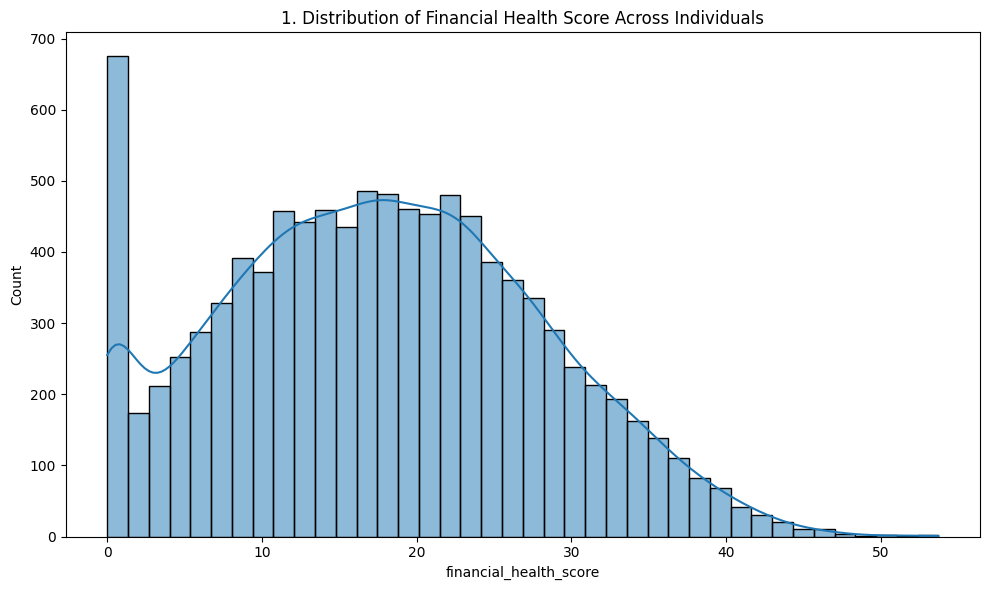

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['financial_health_score'], kde=True)
plt.title(f'{plot_no}. Distribution of Financial Health Score Across Individuals')
show_fig()
plot_no += 1

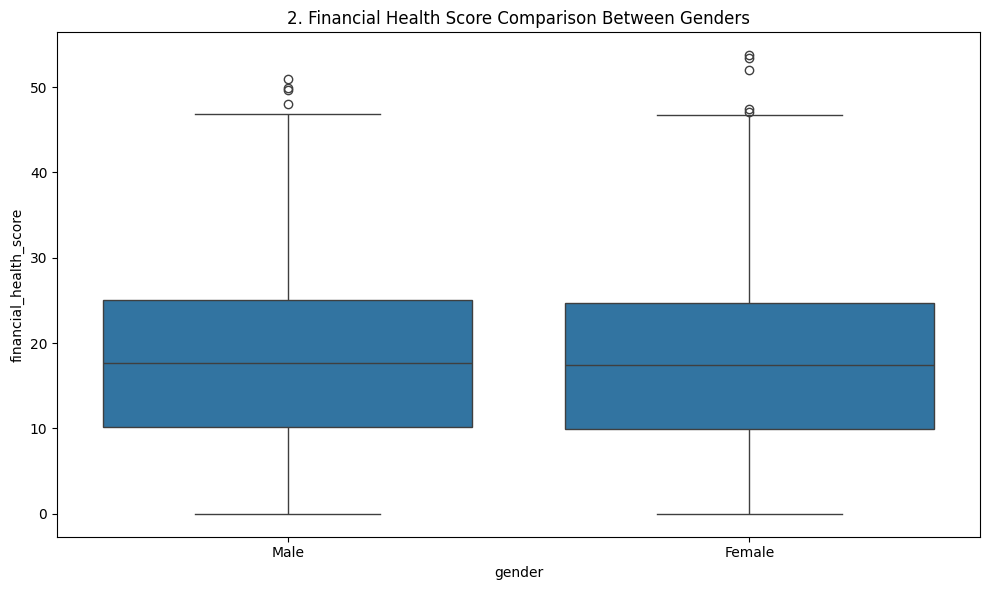

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Financial Health Score Comparison Between Genders')
show_fig()
plot_no += 1

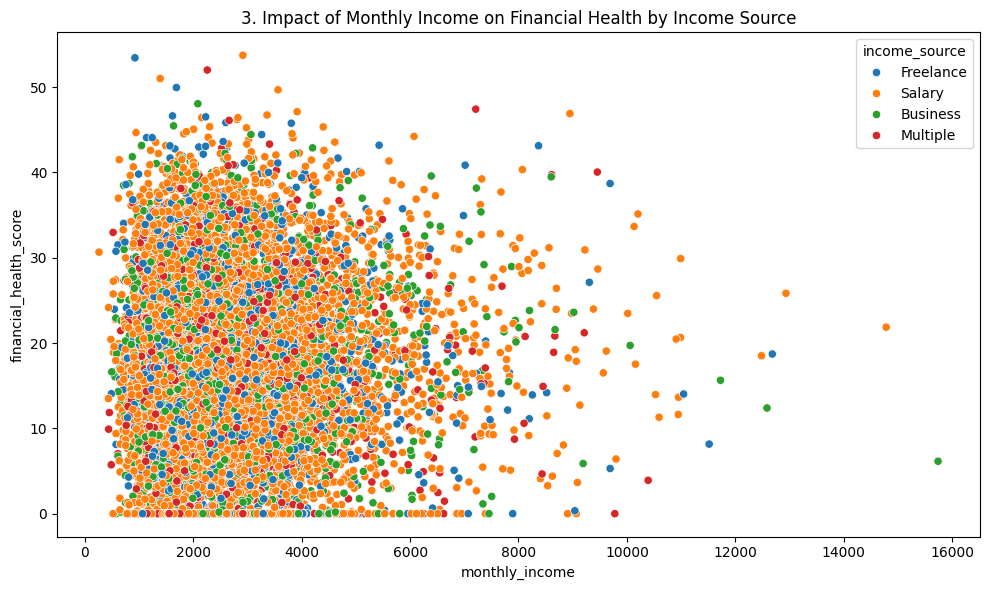

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='monthly_income', y='financial_health_score', hue='income_source', data=df)
plt.title(f'{plot_no}. Impact of Monthly Income on Financial Health by Income Source')
show_fig()
plot_no += 1

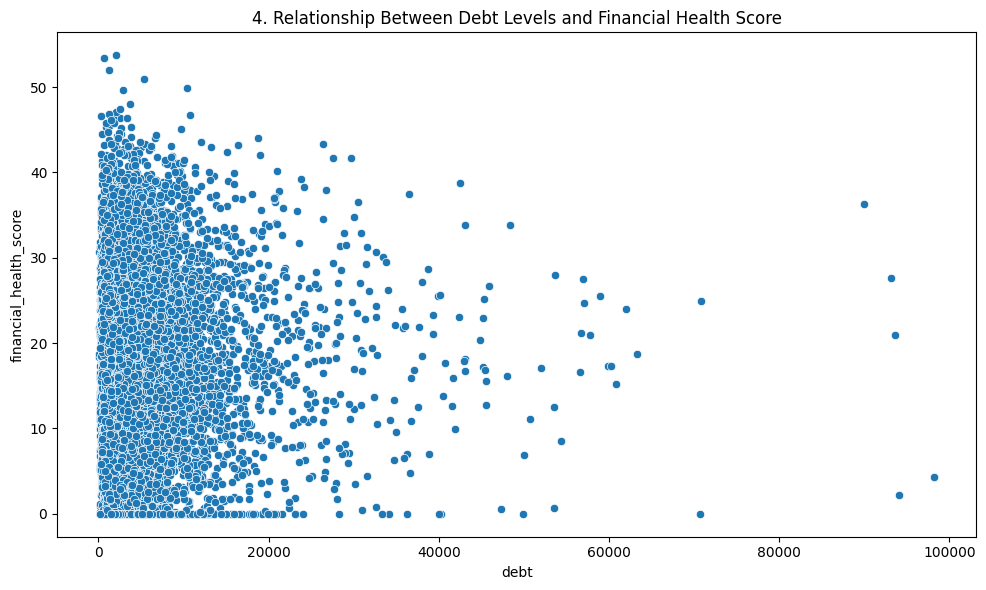

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='debt', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Relationship Between Debt Levels and Financial Health Score')
show_fig()
plot_no += 1

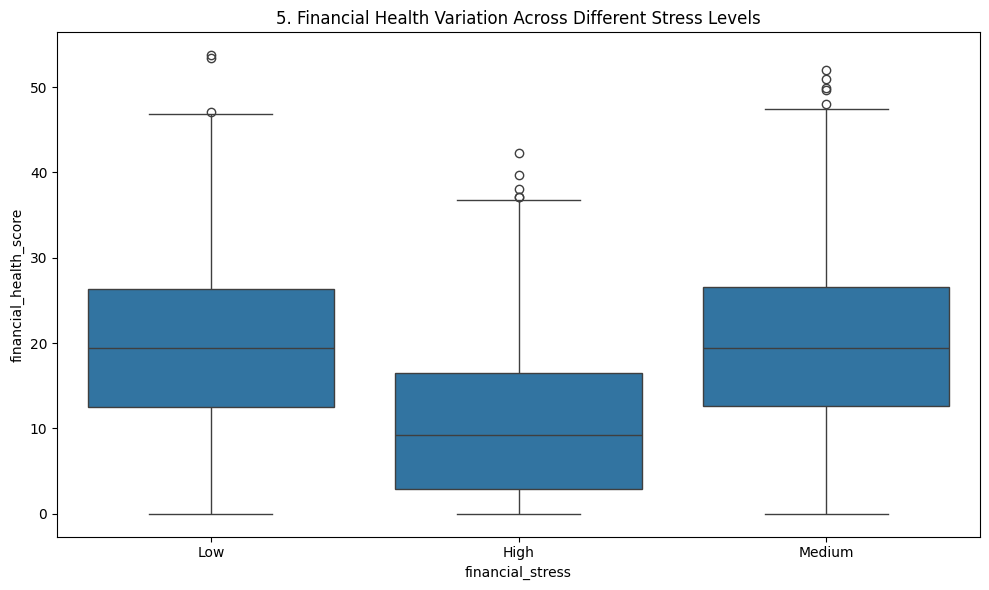

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='financial_stress', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Financial Health Variation Across Different Stress Levels')
show_fig()
plot_no += 1

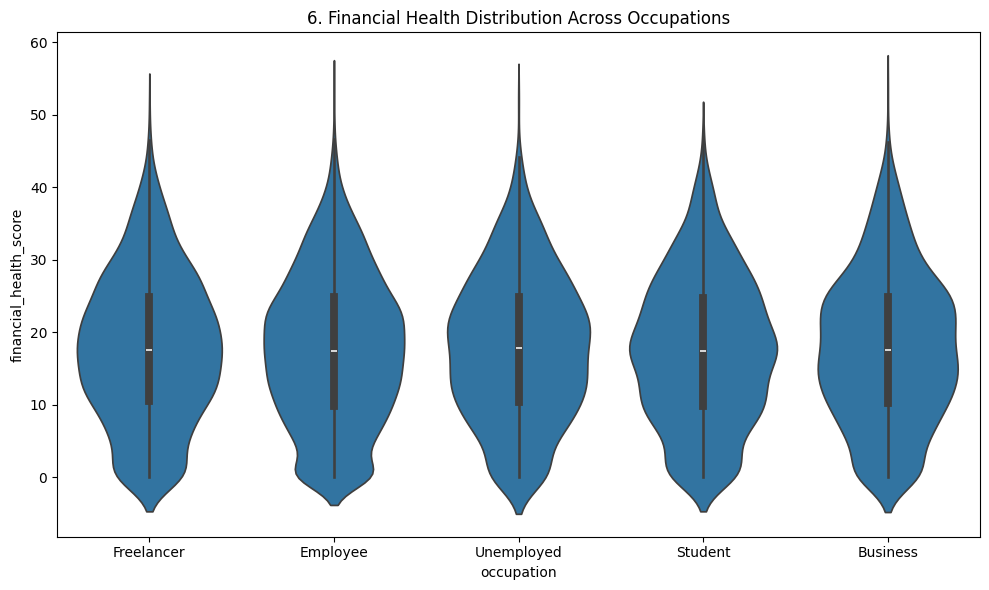

In [18]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='occupation', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Financial Health Distribution Across Occupations')
show_fig()
plot_no += 1

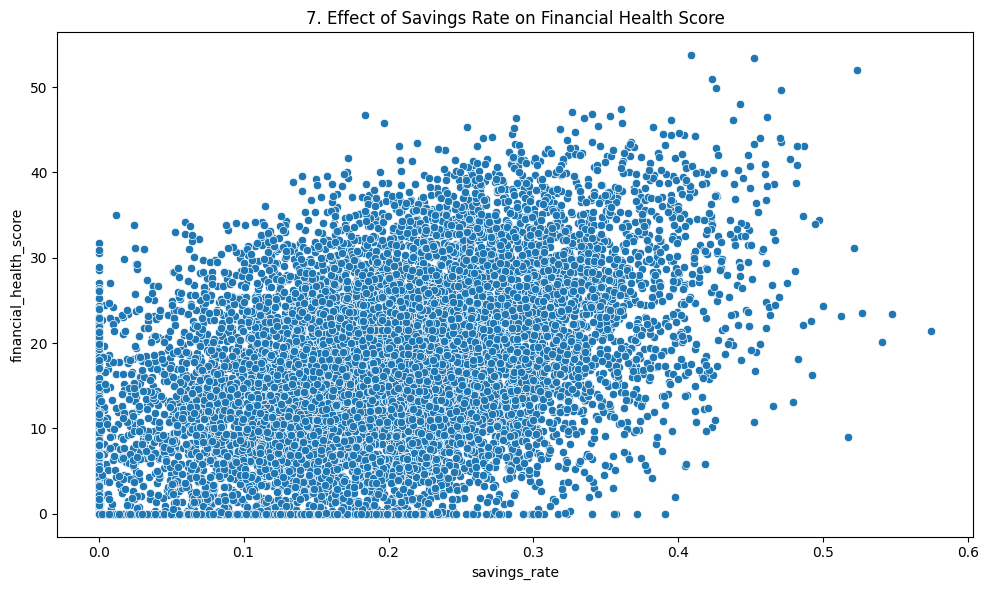

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='savings_rate', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Effect of Savings Rate on Financial Health Score')
show_fig()
plot_no += 1

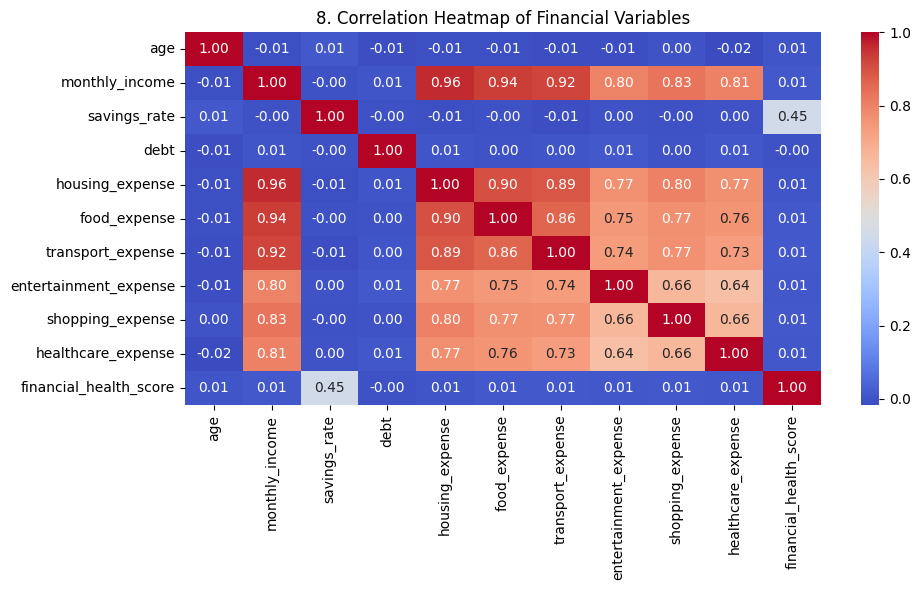

In [20]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Financial Variables')
show_fig()
plot_no += 1

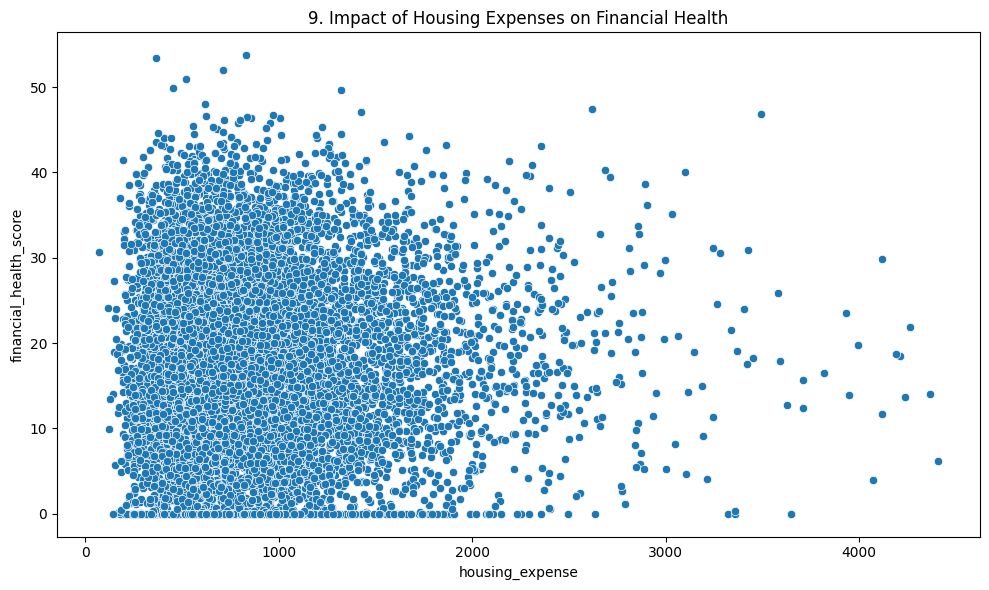

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='housing_expense', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Impact of Housing Expenses on Financial Health')
show_fig()
plot_no += 1

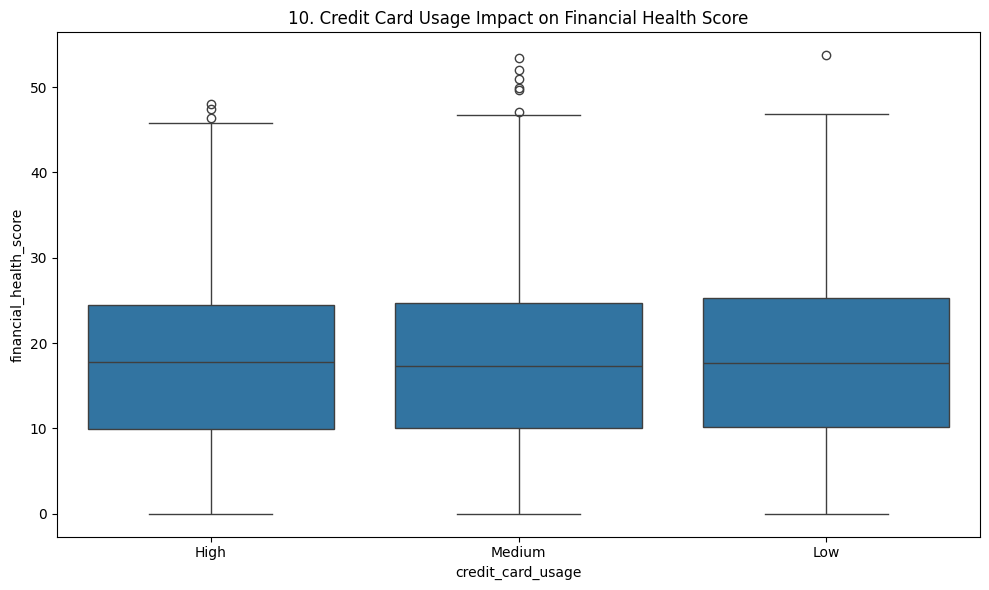

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='credit_card_usage', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Credit Card Usage Impact on Financial Health Score')
show_fig()
plot_no += 1

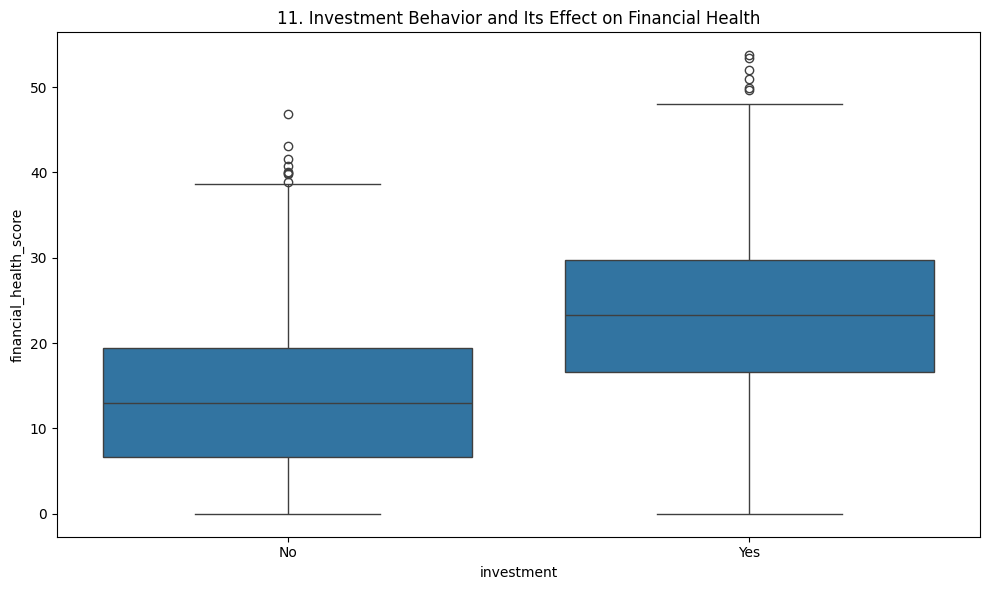

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='investment', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Investment Behavior and Its Effect on Financial Health')
show_fig()
plot_no += 1

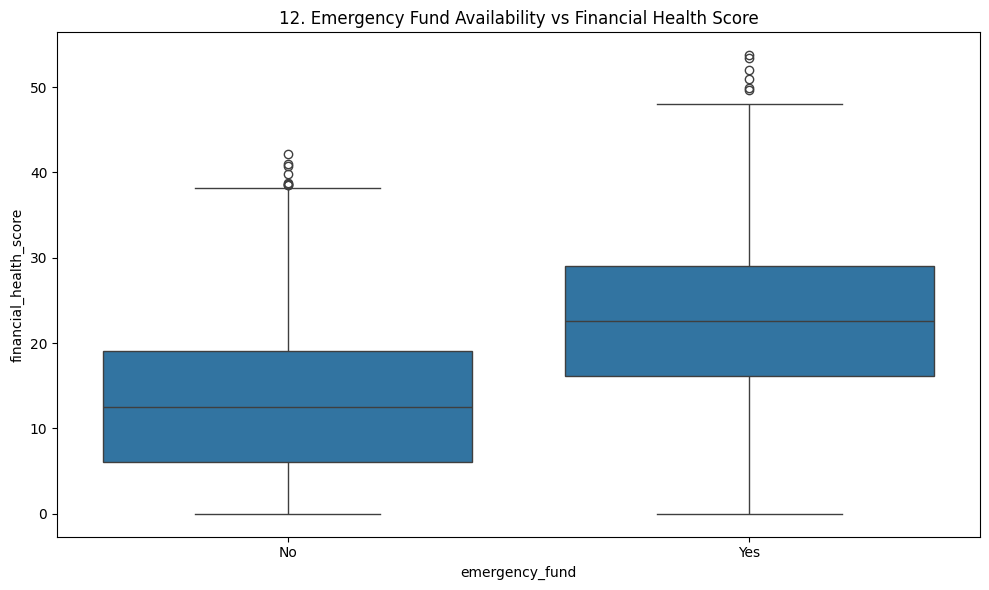

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='emergency_fund', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Emergency Fund Availability vs Financial Health Score')
show_fig()
plot_no += 1

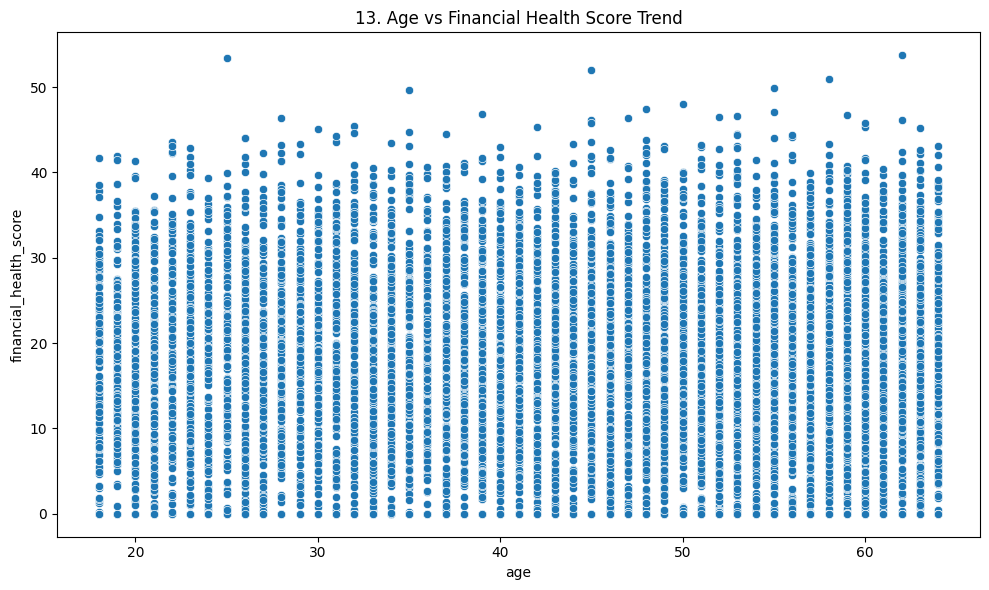

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='financial_health_score', data=df)
plt.title(f'{plot_no}. Age vs Financial Health Score Trend')
show_fig()
plot_no += 1

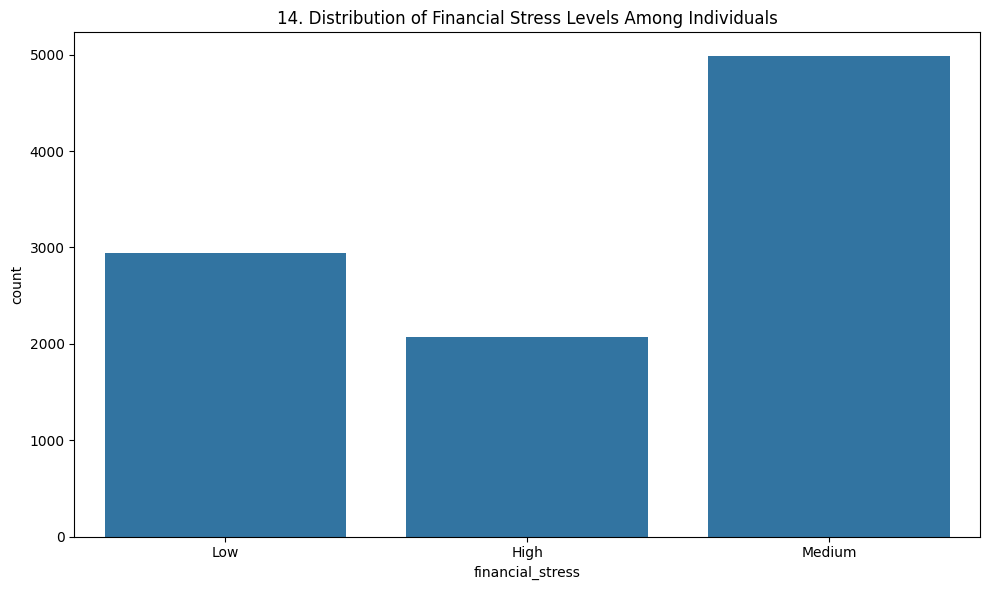

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='financial_stress', data=df)
plt.title(f'{plot_no}. Distribution of Financial Stress Levels Among Individuals')
show_fig()
plot_no += 1

# Model Training

## encode categorical columns

In [27]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

## define features and target

In [28]:
X = df_encoded.drop('financial_stress', axis=1)
y = df_encoded['financial_stress']

## split the dataset

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## apply feature scaling

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## apply hyperparameter tuning for SVM

In [31]:
param_grid = {'C':[0.1,1,10],'kernel':['rbf','linear'],'gamma':['scale','auto']}
grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


## train best model

In [32]:
model = grid.best_estimator_

## make predictions

In [33]:
y_pred = model.predict(X_test)

## print accuracy score

In [34]:
print("Best Params:", grid.best_params_)
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy Score: 0.6065


## plot confusion matrix

<Figure size 1000x600 with 0 Axes>

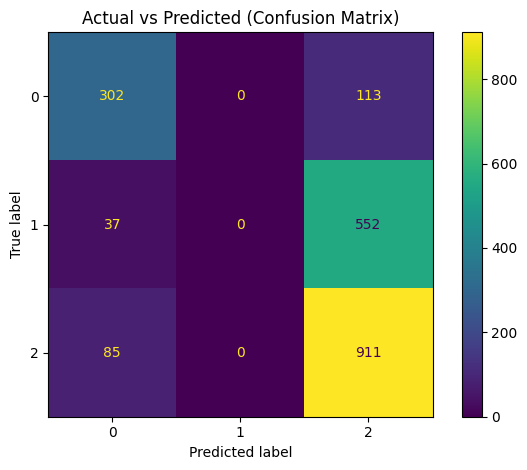

In [35]:
fig = plt.figure(figsize=(10,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()